In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [14]:
image = cv2.imread('/Users/230108/Downloads/images-2.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

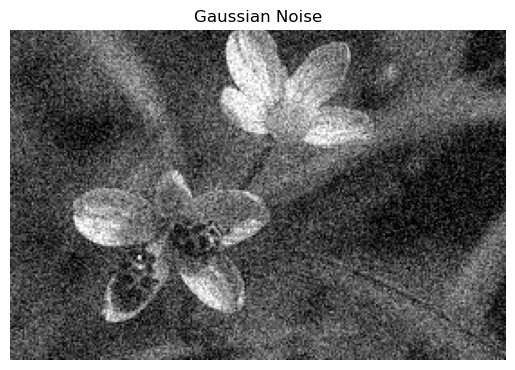

In [25]:
noise = np.random.normal(0, 25, image.shape)
noisy = image + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

plt.imshow(noisy, cmap='gray')
plt.title("Gaussian Noise")
plt.axis('off')
plt.show()

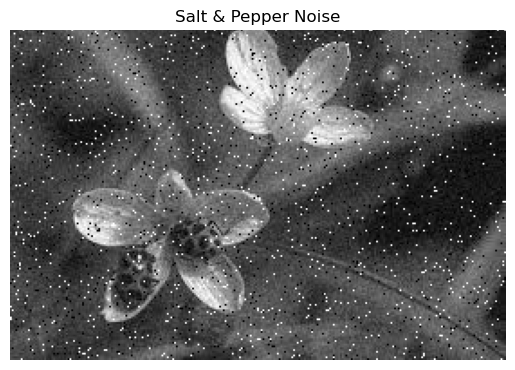

In [29]:
sp = image.copy()

prob = 0.02

salt = np.random.rand(*image.shape) < prob
sp[salt] = 255

pepper = np.random.rand(*image.shape) < prob
sp[pepper] = 0

plt.imshow(sp, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')
plt.show()

In [33]:
def add_uniform_noise(img):
    noise = np.random.uniform(-30, 30, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

gaussian_noise = add_gaussian_noise(image)
sp_noise = add_salt_pepper_noise(image)
uniform_noise = add_uniform_noise(image)

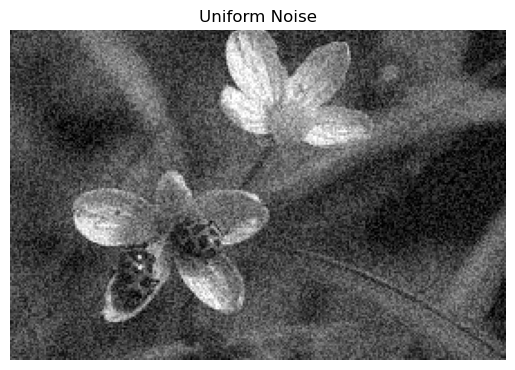

In [38]:
uniform = image + np.random.uniform(-30, 30, image.shape)
uniform = np.clip(uniform, 0, 255).astype(np.uint8)

plt.imshow(uniform, cmap='gray')
plt.title("Uniform Noise")
plt.axis('off')
plt.show()

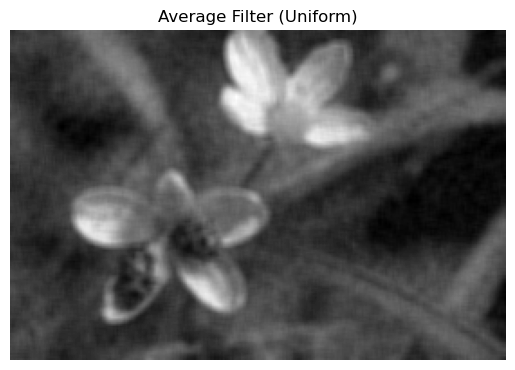

In [40]:
average = cv2.blur(uniform, (5,5))

plt.imshow(average, cmap='gray')
plt.title("Average Filter (Uniform)")
plt.axis('off')
plt.show()

In [43]:
def mse(a, b):
    return np.mean((a - b) ** 2)

def psnr(a, b):
    m = mse(a, b)
    if m == 0:
        return 100
    return 10 * np.log10((255**2) / m)

print("Salt & Pepper -> MSE:", mse(image, median))
print("Salt & Pepper -> PSNR:", psnr(image, median))

print("Uniform -> MSE:", mse(image, average))
print("Uniform -> PSNR:", psnr(image, average))

Salt & Pepper -> MSE: 58.37420765027323
Salt & Pepper -> PSNR: 30.468593622050825
Uniform -> MSE: 64.56401390958769
Uniform -> PSNR: 30.030898384631254


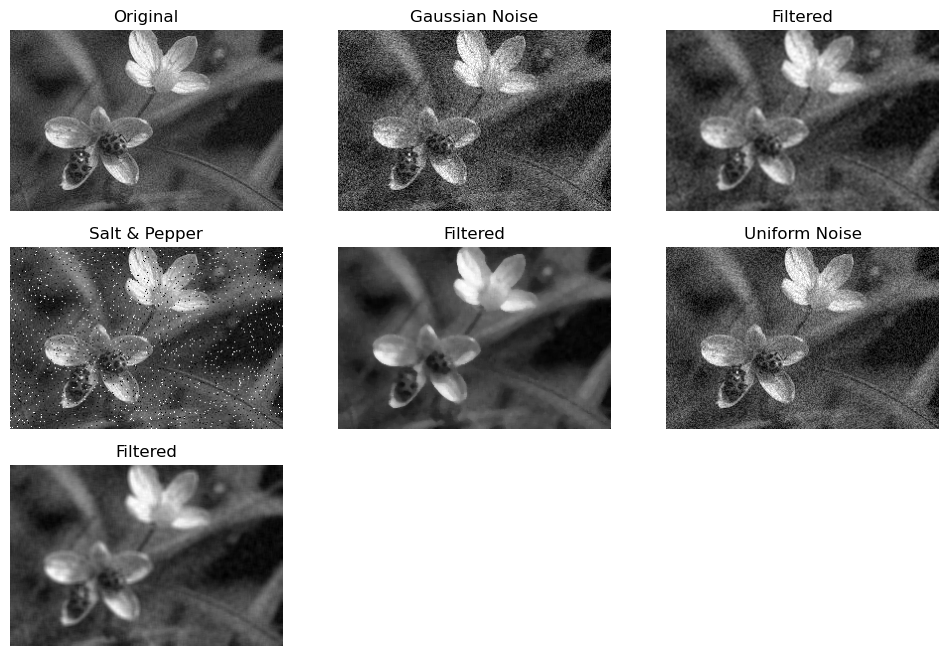

In [42]:
titles = ['Original', 'Gaussian Noise', 'Filtered',
          'Salt & Pepper', 'Filtered',
          'Uniform Noise', 'Filtered']

images = [image, gaussian_noise, gaussian_filtered,
          sp_noise, median_filtered,
          uniform_noise, average_filtered]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()